Original data shape: (62988, 44)
All data columns: ['MEMBER_NO', 'FFP_DATE', 'FIRST_FLIGHT_DATE', 'GENDER', 'FFP_TIER', 'WORK_CITY', 'WORK_PROVINCE', 'WORK_COUNTRY', 'AGE', 'LOAD_TIME', 'FLIGHT_COUNT', 'BP_SUM', 'EP_SUM_YR_1', 'EP_SUM_YR_2', 'SUM_YR_1', 'SUM_YR_2', 'SEG_KM_SUM', 'WEIGHTED_SEG_KM', 'LAST_FLIGHT_DATE', 'AVG_FLIGHT_COUNT', 'AVG_BP_SUM', 'BEGIN_TO_FIRST', 'LAST_TO_END', 'AVG_INTERVAL', 'MAX_INTERVAL', 'ADD_POINTS_SUM_YR_1', 'ADD_POINTS_SUM_YR_2', 'EXCHANGE_COUNT', 'avg_discount', 'P1Y_Flight_Count', 'L1Y_Flight_Count', 'P1Y_BP_SUM', 'L1Y_BP_SUM', 'EP_SUM', 'ADD_Point_SUM', 'Eli_Add_Point_Sum', 'L1Y_ELi_Add_Points', 'Points_Sum', 'L1Y_Points_Sum', 'Ration_L1Y_Flight_Count', 'Ration_P1Y_Flight_Count', 'Ration_P1Y_BPS', 'Ration_L1Y_BPS', 'Point_NotFlight']
Data shape after deduplication: (62988, 44)

Missing values statistics for key fields after preprocessing:
Points_Sum            0
L1Y_Points_Sum        0
WEIGHTED_SEG_KM       0
P1Y_Flight_Count      0
FLIGHT_COUNT        

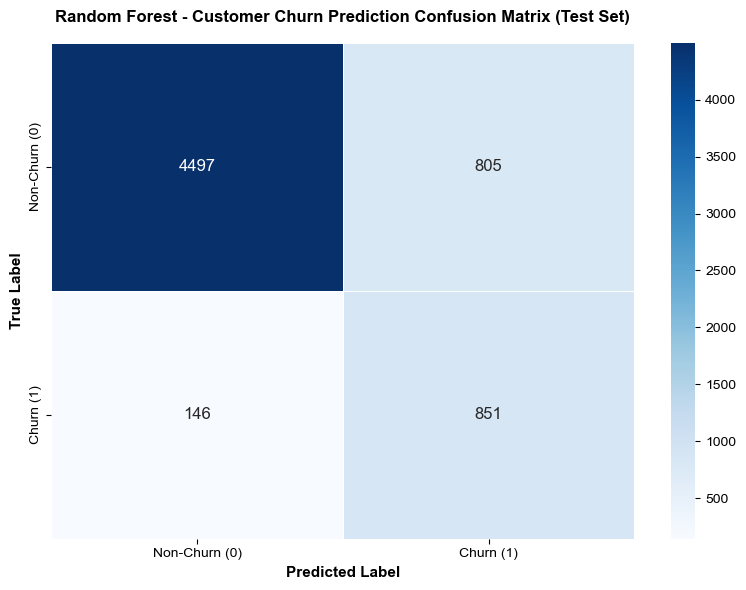


===================== Confusion Matrix Interpretation =====================
True Negatives (TN): 4497 → Correctly predicted non-churners
False Positives (FP): 805 → Falsely predicted as churners (false alarms, increase operational cost)
False Negatives (FN): 146 → Missed actual churners (critical errors, no intervention)
True Positives (TP): 851 → Correctly predicted churners (effective intervention targets)


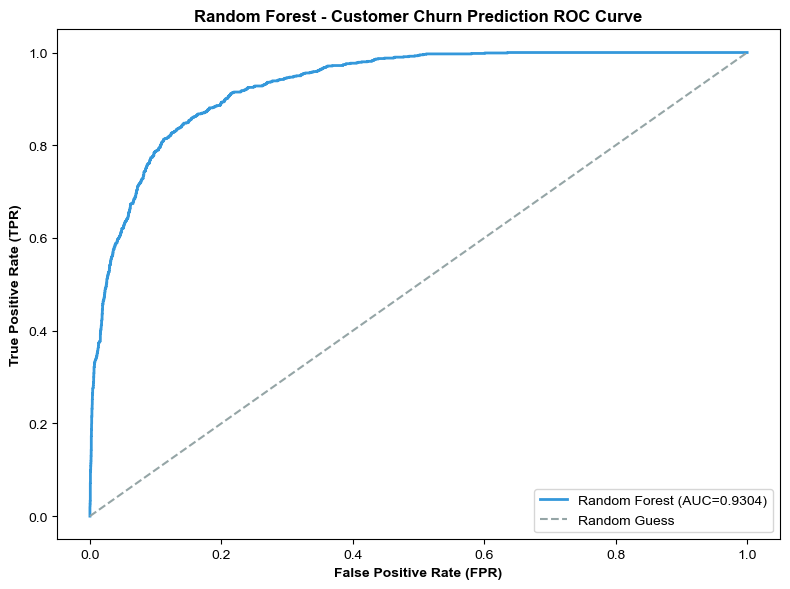

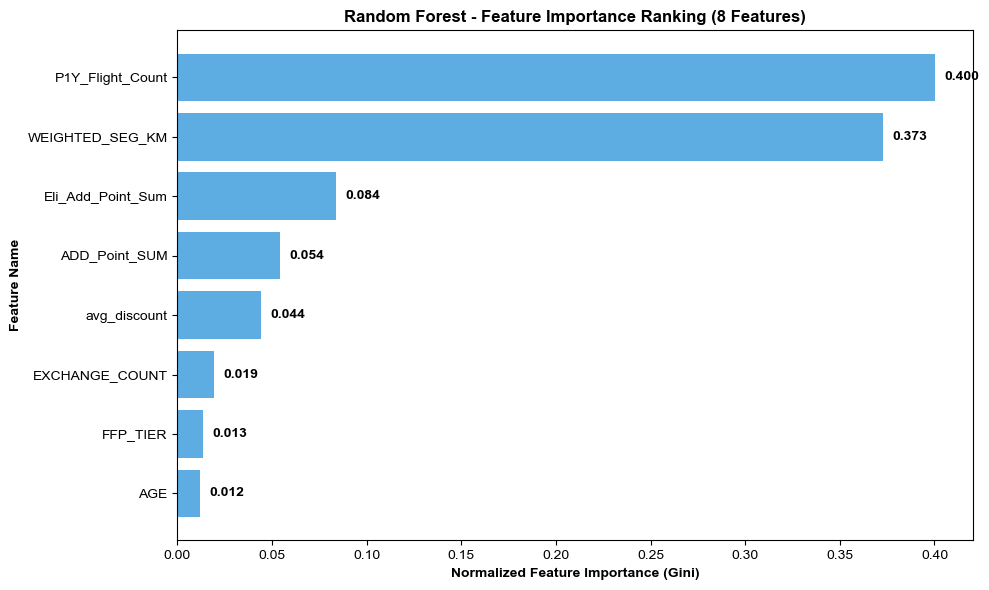

In [11]:
# ===================== Step 1: Environment Configuration & Library Import =====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, roc_curve, confusion_matrix
)

# Global Configuration (Fix font/negative sign display, unify plot style)
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 10
warnings.filterwarnings("ignore")  # Suppress non-critical warnings

# ===================== Step 2: Data Loading & Preprocessing =====================
def load_and_preprocess_data(file_path):
    """
    Complete data preprocessing pipeline:
    1. Load data
    2. Standardize formats (numeric fields)
    3. Handle duplicates/missing values
    4. Keep only necessary fields to avoid missing column errors
    """
    # 1. Load data
    df = pd.read_csv(file_path)
    print(f"Original data shape: {df.shape}")
    print(f"All data columns: {df.columns.tolist()}")  # Add: Print columns for verification

    # 2. Remove duplicates
    df = df.drop_duplicates()
    print(f"Data shape after deduplication: {df.shape}")

    # 3. Standardize field formats (process only existing fields)
    # 3.1 Feature columns (specified 8 features)
    feature_cols = [
        'FFP_TIER', 'AGE', 'WEIGHTED_SEG_KM', 'EXCHANGE_COUNT',
        'avg_discount', 'P1Y_Flight_Count', 'ADD_Point_SUM', 'Eli_Add_Point_Sum'
    ]
    # 3.2 Columns required for churn label calculation (keep only existing ones)
    label_cols = [
        "L1Y_Flight_Count", "L1Y_Points_Sum", "L1Y_ELi_Add_Points",
        "P1Y_Flight_Count", "FLIGHT_COUNT", "Points_Sum"
    ]
    # Merge numeric columns to process
    numeric_cols = list(set(feature_cols + label_cols))
    # Keep only columns present in data
    numeric_cols = [col for col in numeric_cols if col in df.columns]

    # Convert to numeric type
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # 4. Fill missing values (median for numeric fields)
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

    # Verify preprocessing results
    print("\nMissing values statistics for key fields after preprocessing:")
    print(df[numeric_cols].isnull().sum())

    return df

# ===================== Step 3: Churn Label Definition (Fix Missing Fields Issue) =====================
def calculate_churn_label(df):
    """
    Define churn label:
    - Churn (1): No flight/points/exchange in last year + Historical active behavior
    - Non-Churn (0): Does not meet the above conditions
    Fix: Use only existing fields, remove dependency on P1Y_Points_Sum
    """
    # Mandatory field check (only core fields)
    core_label_cols = ["L1Y_Flight_Count", "L1Y_Points_Sum", "L1Y_ELi_Add_Points"]
    missing_core_cols = [col for col in core_label_cols if col not in df.columns]
    if missing_core_cols:
        raise ValueError(f"Missing core fields for churn label calculation: {missing_core_cols}")

    # 1. Current inactive status (no behavior in last year)
    inactive_now = (
        (df["L1Y_Flight_Count"] == 0) &
        (df["L1Y_Points_Sum"] == 0) &
        (df["L1Y_ELi_Add_Points"] == 0)
    )

    # 2. Historical active status (use only existing fields)
    active_conditions = []
    # Prioritize P1Y_Flight_Count if exists
    if "P1Y_Flight_Count" in df.columns:
        active_conditions.append(df["P1Y_Flight_Count"] > 0)
    # Then use FLIGHT_COUNT (total flights) if exists
    if "FLIGHT_COUNT" in df.columns:
        active_conditions.append(df["FLIGHT_COUNT"] > 0)
    # Finally use Points_Sum (total points) if exists
    if "Points_Sum" in df.columns:
        active_conditions.append(df["Points_Sum"] > 0)

    # Ensure at least one active condition
    if not active_conditions:
        raise ValueError("No available fields to judge historical active status. Please check if data contains P1Y_Flight_Count/FLIGHT_COUNT/Points_Sum")

    historical_active = np.logical_or.reduce(active_conditions)

    # 3. Final churn label
    df["is_churn"] = (inactive_now & historical_active).astype(int)

    # Output label distribution
    print(f"\nChurn label distribution:")
    print(df["is_churn"].value_counts())
    print(f"Churn rate: {df['is_churn'].mean() * 100:.2f}%")

    return df

# ===================== Step 4: Stratified Data Split (8:1:1) =====================
def split_data_stratified(df, feature_list, target_col="is_churn", random_state=42):
    """
    Stratified split into training set (80%), test set (10%), validation set (10%)
    Ensure consistent churn rate across all sets
    """
    # Select features and labels (remove missing values)
    X = df[feature_list].dropna()
    y = df.loc[X.index, target_col]

    # Step 1: Split into training set (80%) and temp set (20%)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )
    # Step 2: Split temp set into test set (10%) and validation set (10%)
    X_test, X_val, y_test, y_val = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=random_state, stratify=y_temp
    )

    # Verify split results
    print(f"\nData split results:")
    print(f"Training set: {len(X_train)} samples (Churn rate: {y_train.mean()*100:.2f}%)")
    print(f"Test set: {len(X_test)} samples (Churn rate: {y_test.mean()*100:.2f}%)")
    print(f"Validation set: {len(X_val)} samples (Churn rate: {y_val.mean()*100:.2f}%)")

    return X_train, X_test, X_val, y_train, y_test, y_val

# ===================== Step 5: Random Forest Modeling (GridSearchCV Tuning) =====================
def train_random_forest(X_train, X_val, y_train, y_val):
    """
    Random Forest training + GridSearchCV parameter tuning
    """
    # Define parameter grid (core tuning parameters)
    param_grid = {
        'n_estimators': [50, 100, 150],        # Number of decision trees
        'max_depth': [6, 8, 10],              # Maximum tree depth (control overfitting)
        'min_samples_split': [10, 20],        # Minimum samples required to split a node
        'class_weight': ['balanced'],         # Class balance (solve data imbalance)
        'random_state': [42]
    }

    # Initialize model
    rf = RandomForestClassifier(n_jobs=-1)

    # Grid Search (5-fold cross-validation, ROC-AUC as evaluation metric)
    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )

    # Train model
    print("\nStarting GridSearchCV tuning...")
    grid_search.fit(X_train, y_train)

    # Best model and parameters
    best_rf = grid_search.best_estimator_
    best_params = grid_search.best_params_
    cv_auc = grid_search.best_score_

    # Validation set evaluation
    val_proba = best_rf.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, val_proba)

    # Output tuning results
    print(f"\nBest parameters: {best_params}")
    print(f"Training set cross-validation AUC: {cv_auc:.4f}")
    print(f"Validation set AUC: {val_auc:.4f}")

    return best_rf, best_params

# ===================== Step 6: Model Evaluation & Visualization (English Labels) =====================
def evaluate_model(model, X_test, y_test, feature_list):
    """
    Model evaluation: Core metrics + ROC Curve + Feature Importance + Confusion Matrix
    All labels/legends in English to avoid display issues
    """
    # Prediction results
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    # Calculate core metrics
    metrics = {
        "AUC": round(roc_auc_score(y_test, y_proba), 4),
        "Recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "F1": round(f1_score(y_test, y_pred, zero_division=0), 4),
        "Accuracy": round(accuracy_score(y_test, y_pred), 4)
    }

    # Print evaluation results
    print("\n===================== Model Evaluation Results =====================")
    print(f"AUC: {metrics['AUC']}")
    print(f"Churn Recall: {metrics['Recall']} (Covers {metrics['Recall']*100:.1f}% of actual churners)")
    print(f"Churn Precision: {metrics['Precision']}")
    print(f"F1 Score: {metrics['F1']}")
    print(f"Accuracy: {metrics['Accuracy']}")
    print("\nDetailed Classification Report:")
    print(classification_report(
        y_test, y_pred,
        target_names=["Non-Churn", "Churn"],
        digits=4
    ))

    # 1. Confusion Matrix Visualization (Core new feature)
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)  # Calculate confusion matrix
    # Plot heatmap with values annotated
    sns.heatmap(cm,
                annot=True,  # Show cell values
                fmt="d",  # Numeric format: integer
                cmap="Blues",  # Color scheme (blue series for better readability)
                xticklabels=["Non-Churn (0)", "Churn (1)"],
                yticklabels=["Non-Churn (0)", "Churn (1)"],
                cbar=True,
                linewidths=0.5,
                annot_kws={"size": 12})  # Annotation font size
    plt.xlabel("Predicted Label", fontweight="bold", fontsize=11)
    plt.ylabel("True Label", fontweight="bold", fontsize=11)
    plt.title("Random Forest - Customer Churn Prediction Confusion Matrix (Test Set)", fontweight="bold", fontsize=12, pad=15)
    plt.tight_layout()
    plt.show()

    # Confusion Matrix Interpretation (Business perspective)
    tn, fp, fn, tp = cm.ravel()
    print("\n===================== Confusion Matrix Interpretation =====================")
    print(f"True Negatives (TN): {tn} → Correctly predicted non-churners")
    print(f"False Positives (FP): {fp} → Falsely predicted as churners (false alarms, increase operational cost)")
    print(f"False Negatives (FN): {fn} → Missed actual churners (critical errors, no intervention)")
    print(f"True Positives (TP): {tp} → Correctly predicted churners (effective intervention targets)")

    # 2. ROC Curve Visualization
    plt.figure()
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, color="#3498db", linewidth=2, label=f"Random Forest (AUC={metrics['AUC']})")
    plt.plot([0, 1], [0, 1], color="#95a5a6", linestyle="--", label="Random Guess")
    plt.xlabel("False Positive Rate (FPR)", fontweight="bold")
    plt.ylabel("True Positive Rate (TPR)", fontweight="bold")
    plt.title("Random Forest - Customer Churn Prediction ROC Curve", fontweight="bold")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    # 3. Feature Importance Visualization (Show only 8 specified features)
    plt.figure(figsize=(10, 6))
    importance = model.feature_importances_
    imp_df = pd.DataFrame({
        "Feature": feature_list,
        "Importance": importance / importance.sum()  # Normalization
    }).sort_values("Importance", ascending=True)

    plt.barh(imp_df["Feature"], imp_df["Importance"], color="#3498db", alpha=0.8)
    for i, val in enumerate(imp_df["Importance"]):
        plt.text(val + 0.005, i, f"{val:.3f}", ha="left", va="center", fontweight="bold")
    plt.xlabel("Normalized Feature Importance (Gini)", fontweight="bold")
    plt.ylabel("Feature Name", fontweight="bold")
    plt.title("Random Forest - Feature Importance Ranking (8 Features)", fontweight="bold")
    plt.tight_layout()
    plt.show()

    return metrics

# ===================== Main Pipeline Execution =====================
if __name__ == "__main__":
    # 1. Data path (replace with your actual CSV path)
    FILE_PATH = "/Users/mac123/Downloads/air_data.csv"

    # 2. Data preprocessing (add column list printing)
    df = load_and_preprocess_data(FILE_PATH)

    # 3. Generate churn label (fix missing fields issue)
    df = calculate_churn_label(df)

    # 4. Strictly use specified 8 features
    FEATURE_LIST = [
        'FFP_TIER', 'AGE', 'WEIGHTED_SEG_KM', 'EXCHANGE_COUNT',
        'avg_discount', 'P1Y_Flight_Count', 'ADD_Point_SUM', 'Eli_Add_Point_Sum'
    ]
    # Filter features present in data
    FEATURE_LIST = [col for col in FEATURE_LIST if col in df.columns]
    print(f"\nFinal feature list used: {FEATURE_LIST}")
    # Verify feature count
    if len(FEATURE_LIST) != 8:
        missing_feat = [f for f in ['FFP_TIER', 'AGE', 'WEIGHTED_SEG_KM', 'EXCHANGE_COUNT',
                                    'avg_discount', 'P1Y_Flight_Count', 'ADD_Point_SUM', 'Eli_Add_Point_Sum']
                        if f not in FEATURE_LIST]
        print(f"Warning: Missing specified features {missing_feat}. Currently using {len(FEATURE_LIST)} features.")

    # 5. Stratified data split
    X_train, X_test, X_val, y_train, y_test, y_val = split_data_stratified(df, FEATURE_LIST)

    # 6. Train Random Forest model
    best_rf_model, best_params = train_random_forest(X_train, X_val, y_train, y_val)

    # 7. Model evaluation (including confusion matrix)
    metrics = evaluate_model(best_rf_model, X_test, y_test, FEATURE_LIST)

原始数据形状: (62988, 44)
数据所有字段: ['MEMBER_NO', 'FFP_DATE', 'FIRST_FLIGHT_DATE', 'GENDER', 'FFP_TIER', 'WORK_CITY', 'WORK_PROVINCE', 'WORK_COUNTRY', 'AGE', 'LOAD_TIME', 'FLIGHT_COUNT', 'BP_SUM', 'EP_SUM_YR_1', 'EP_SUM_YR_2', 'SUM_YR_1', 'SUM_YR_2', 'SEG_KM_SUM', 'WEIGHTED_SEG_KM', 'LAST_FLIGHT_DATE', 'AVG_FLIGHT_COUNT', 'AVG_BP_SUM', 'BEGIN_TO_FIRST', 'LAST_TO_END', 'AVG_INTERVAL', 'MAX_INTERVAL', 'ADD_POINTS_SUM_YR_1', 'ADD_POINTS_SUM_YR_2', 'EXCHANGE_COUNT', 'avg_discount', 'P1Y_Flight_Count', 'L1Y_Flight_Count', 'P1Y_BP_SUM', 'L1Y_BP_SUM', 'EP_SUM', 'ADD_Point_SUM', 'Eli_Add_Point_Sum', 'L1Y_ELi_Add_Points', 'Points_Sum', 'L1Y_Points_Sum', 'Ration_L1Y_Flight_Count', 'Ration_P1Y_Flight_Count', 'Ration_P1Y_BPS', 'Ration_L1Y_BPS', 'Point_NotFlight']
去重后数据形状: (62988, 44)

预处理后关键字段缺失值统计:
Points_Sum            0
L1Y_Points_Sum        0
WEIGHTED_SEG_KM       0
P1Y_Flight_Count      0
FLIGHT_COUNT          0
L1Y_ELi_Add_Points    0
FFP_TIER              0
EXCHANGE_COUNT        0
ADD_Point_SUM    

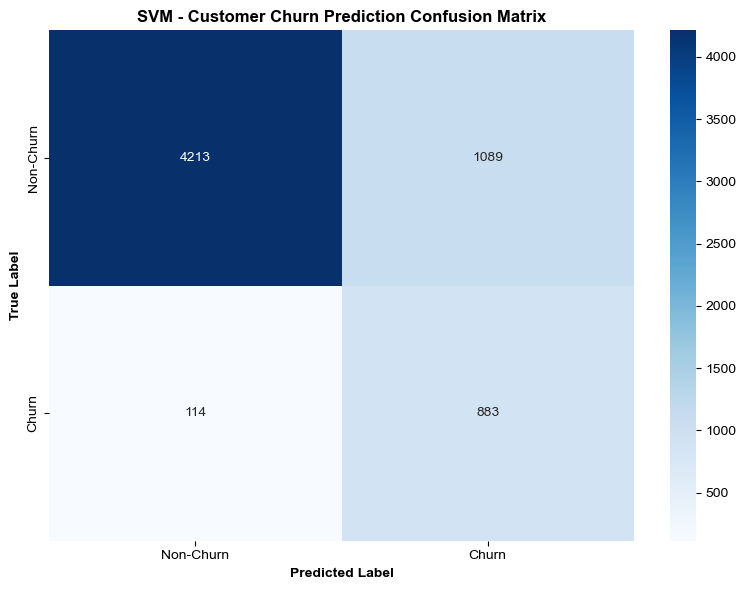

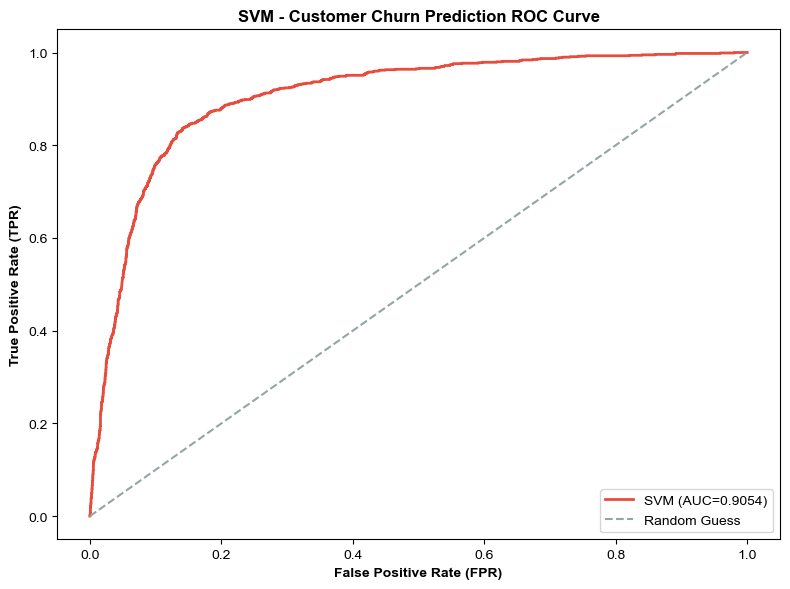

Exception ignored in: <function ResourceTracker.__del__ at 0x1041c5e40>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1072ede40>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1031b1e40>
Traceback (most recent call last

In [12]:
# ===================== 第一步：环境配置与库导入 =====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler  # SVM必须的特征标准化
from sklearn.pipeline import Pipeline  # 构建标准化+建模的流水线
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, roc_curve, confusion_matrix
)
import seaborn as sns

# 全局配置（解决中文/负号显示问题，统一图表样式）
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 10
warnings.filterwarnings("ignore")  # 抑制非关键警告

# ===================== 第二步：数据读取与预处理 =====================
def load_and_preprocess_data(file_path):
    """
    完整数据预处理流程：
    1. 读取数据
    2. 格式标准化（日期/数值/分类字段）
    3. 缺失值/重复值处理
    4. 仅保留必要字段，避免引用缺失列
    """
    # 1. 读取数据
    df = pd.read_csv(file_path)
    print(f"原始数据形状: {df.shape}")
    print(f"数据所有字段: {df.columns.tolist()}")  # 新增：打印所有字段，方便核对

    # 2. 去重
    df = df.drop_duplicates()
    print(f"去重后数据形状: {df.shape}")

    # 3. 字段格式标准化（仅处理存在的字段）
    # 3.1 特征字段（指定的8个）
    feature_cols = [
        'FFP_TIER', 'AGE', 'WEIGHTED_SEG_KM', 'EXCHANGE_COUNT',
        'avg_discount', 'P1Y_Flight_Count', 'ADD_Point_SUM', 'Eli_Add_Point_Sum'
    ]
    # 3.2 标签计算所需字段（仅保留数据中存在的）
    label_cols = [
        "L1Y_Flight_Count", "L1Y_Points_Sum", "L1Y_ELi_Add_Points",
        "P1Y_Flight_Count", "FLIGHT_COUNT", "Points_Sum"
    ]
    # 合并需要处理的数值字段
    numeric_cols = list(set(feature_cols + label_cols))
    # 只处理数据中存在的字段
    numeric_cols = [col for col in numeric_cols if col in df.columns]

    # 转换为数值型
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # 4. 缺失值填充（数值字段用中位数）
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

    # 验证预处理结果
    print("\n预处理后关键字段缺失值统计:")
    print(df[numeric_cols].isnull().sum())

    return df

# ===================== 第三步：流失标签定义（修复缺失字段问题） =====================
def calculate_churn_label(df):
    """
    定义流失标签：
    - 流失（1）：近1年无飞行/无积分/无兑换行为 + 历史有活跃行为
    - 未流失（0）：不符合上述条件
    修复：仅使用数据中存在的字段，移除对P1Y_Points_Sum的依赖
    """
    # 必选字段校验（仅校验核心字段）
    core_label_cols = ["L1Y_Flight_Count", "L1Y_Points_Sum", "L1Y_ELi_Add_Points"]
    missing_core_cols = [col for col in core_label_cols if col not in df.columns]
    if missing_core_cols:
        raise ValueError(f"缺失流失标签核心计算字段: {missing_core_cols}")

    # 1. 当前沉默状态（近1年无任何行为）
    inactive_now = (
        (df["L1Y_Flight_Count"] == 0) &
        (df["L1Y_Points_Sum"] == 0) &
        (df["L1Y_ELi_Add_Points"] == 0)
    )

    # 2. 历史活跃状态（仅使用存在的字段）
    active_conditions = []
    # 优先用P1Y_Flight_Count（如果存在）
    if "P1Y_Flight_Count" in df.columns:
        active_conditions.append(df["P1Y_Flight_Count"] > 0)
    # 其次用FLIGHT_COUNT（总飞行次数，如果存在）
    if "FLIGHT_COUNT" in df.columns:
        active_conditions.append(df["FLIGHT_COUNT"] > 0)
    # 最后用Points_Sum（总积分，如果存在）
    if "Points_Sum" in df.columns:
        active_conditions.append(df["Points_Sum"] > 0)

    # 确保至少有一个活跃条件
    if not active_conditions:
        raise ValueError("无可用的历史活跃状态判断字段，请检查数据是否包含P1Y_Flight_Count/FLIGHT_COUNT/Points_Sum")

    historical_active = np.logical_or.reduce(active_conditions)

    # 3. 最终流失标签
    df["is_churn"] = (inactive_now & historical_active).astype(int)

    # 输出标签分布
    print(f"\n流失标签分布:")
    print(df["is_churn"].value_counts())
    print(f"流失率: {df['is_churn'].mean() * 100:.2f}%")

    return df

# ===================== 第四步：数据划分（8:1:1分层划分） =====================
def split_data_stratified(df, feature_list, target_col="is_churn", random_state=42):
    """
    分层划分训练集(80%)、测试集(10%)、验证集(10%)，保证各集流失率一致
    """
    # 筛选特征和标签（删除缺失值）
    X = df[feature_list].dropna()
    y = df.loc[X.index, target_col]

    # 第一步：划分训练集(80%)和临时集(20%)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )
    # 第二步：划分测试集(10%)和验证集(10%)
    X_test, X_val, y_test, y_val = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=random_state, stratify=y_temp
    )

    # 验证划分结果
    print(f"\n数据划分结果:")
    print(f"训练集: {len(X_train)} 样本 (流失率: {y_train.mean()*100:.2f}%)")
    print(f"测试集: {len(X_test)} 样本 (流失率: {y_test.mean()*100:.2f}%)")
    print(f"验证集: {len(X_val)} 样本 (流失率: {y_val.mean()*100:.2f}%)")

    return X_train, X_test, X_val, y_train, y_test, y_val

# ===================== 第五步：SVM建模（GridSearchCV调优） =====================
def train_svm(X_train, X_val, y_train, y_val):
    """
    SVM模型训练 + GridSearchCV参数调优
    关键：SVM对特征尺度敏感，必须先标准化；使用Pipeline整合标准化和建模
    """
    # 构建流水线：先标准化，再训练SVM
    pipeline = Pipeline([
        ('scaler', StandardScaler()),  # 特征标准化（SVM必须）
        ('svm', SVC(probability=True, random_state=42))  # 启用概率预测（用于AUC计算）
    ])

    # 定义SVM参数网格（核心调优参数）
    # 注：SVM训练速度较慢，参数网格不宜过大
    param_grid = {
        'svm__C': [0.1, 1, 10],          # 惩罚系数（越大惩罚越重）
        'svm__gamma': ['scale', 'auto'], # 核函数系数
        'svm__kernel': ['rbf', 'linear'],# 核函数（rbf适合非线性，linear适合线性）
        'svm__class_weight': ['balanced'] # 类别平衡（解决数据不平衡）
    }

    # 网格搜索（5折交叉验证，ROC-AUC为评估指标）
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,  # 使用所有CPU核心加速
        verbose=1
    )

    # 训练模型
    print("\n开始SVM网格搜索调优...（SVM训练可能较慢，请耐心等待）")
    grid_search.fit(X_train, y_train)

    # 最优模型和参数
    best_svm = grid_search.best_estimator_
    best_params = grid_search.best_params_
    cv_auc = grid_search.best_score_

    # 验证集评估
    val_proba = best_svm.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, val_proba)

    # 输出调优结果
    print(f"\n最优参数: {best_params}")
    print(f"训练集交叉验证AUC: {cv_auc:.4f}")
    print(f"验证集AUC: {val_auc:.4f}")

    return best_svm, best_params

# ===================== 第六步：模型评估与可视化 =====================
def evaluate_model(model, X_test, y_test, feature_list):
    """
    模型评估：核心指标 + ROC曲线 + 混淆矩阵 + 适配SVM的评估逻辑
    注：SVM无原生特征重要性，故移除特征重要性绘图
    """
    # 预测结果
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    # 核心指标计算
    metrics = {
        "AUC": round(roc_auc_score(y_test, y_proba), 4),
        "Recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "F1": round(f1_score(y_test, y_pred, zero_division=0), 4),
        "Accuracy": round(accuracy_score(y_test, y_pred), 4)
    }

    # 打印评估结果（保留中文，方便查看；仅图表用英文）
    print("\n===================== 模型评估结果 =====================")
    print(f"AUC: {metrics['AUC']}")
    print(f"流失召回率: {metrics['Recall']} (覆盖{metrics['Recall']*100:.1f}%真实流失客户)")
    print(f"流失精确率: {metrics['Precision']}")
    print(f"F1分数: {metrics['F1']}")
    print(f"准确率: {metrics['Accuracy']}")
    print("\n详细分类报告:")
    print(classification_report(y_test, y_pred, target_names=["未流失", "流失"], digits=4))

    # 1. 混淆矩阵绘制（全英文）
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Non-Churn", "Churn"],  # 预测标签：英文
                yticklabels=["Non-Churn", "Churn"])  # 真实标签：英文
    plt.xlabel('Predicted Label', fontweight="bold")  # 英文X轴标签
    plt.ylabel('True Label', fontweight="bold")      # 英文Y轴标签
    plt.title("SVM - Customer Churn Prediction Confusion Matrix", fontweight="bold")  # 英文标题
    plt.tight_layout()
    plt.show()

    # 2. ROC曲线绘制（全英文，原有逻辑不变）
    plt.figure()
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, color="#e74c3c", linewidth=2, label=f"SVM (AUC={metrics['AUC']})")  # 英文图例
    plt.plot([0, 1], [0, 1], color="#95a5a6", linestyle="--", label="Random Guess")  # 英文图例
    plt.xlabel("False Positive Rate (FPR)", fontweight="bold")  # 英文X轴标签
    plt.ylabel("True Positive Rate (TPR)", fontweight="bold")  # 英文Y轴标签
    plt.title("SVM - Customer Churn Prediction ROC Curve", fontweight="bold")  # 英文标题
    plt.legend(loc="lower right")  # 图例位置不变
    plt.tight_layout()
    plt.show()

    return metrics

# ===================== 主流程执行 =====================
if __name__ == "__main__":
    # 1. 数据路径（替换为你的实际路径）
    FILE_PATH = "/Users/mac123/Downloads/air_data.csv"

    # 2. 数据预处理（新增打印字段列表）
    df = load_and_preprocess_data(FILE_PATH)

    # 3. 生成流失标签（修复缺失字段问题）
    df = calculate_churn_label(df)

    # 4. 严格使用指定的8个特征
    FEATURE_LIST = [
        'FFP_TIER', 'AGE', 'WEIGHTED_SEG_KM', 'EXCHANGE_COUNT',
        'avg_discount', 'P1Y_Flight_Count', 'ADD_Point_SUM', 'Eli_Add_Point_Sum'
    ]
    # 过滤数据中存在的特征
    FEATURE_LIST = [col for col in FEATURE_LIST if col in df.columns]
    print(f"\n最终使用的特征列表: {FEATURE_LIST}")
    # 校验特征数量
    if len(FEATURE_LIST) != 8:
        missing_feat = [f for f in ['FFP_TIER', 'AGE', 'WEIGHTED_SEG_KM', 'EXCHANGE_COUNT',
                                    'avg_discount', 'P1Y_Flight_Count', 'ADD_Point_SUM', 'Eli_Add_Point_Sum']
                        if f not in FEATURE_LIST]
        print(f"警告：缺失指定特征 {missing_feat}，当前仅使用 {len(FEATURE_LIST)} 个特征")

    # 5. 分层划分数据
    X_train, X_test, X_val, y_train, y_test, y_val = split_data_stratified(df, FEATURE_LIST)

    # 6. 训练SVM模型
    best_svm_model, best_params = train_svm(X_train, X_val, y_train, y_val)

    # 7. 模型评估
    metrics = evaluate_model(best_svm_model, X_test, y_test, FEATURE_LIST)